Gaussion Mixture

In [3]:

pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 156.1 kB/s eta 0:00:0000:0100:03

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from sklearn.mixture import GaussianMixture 

gmm = GaussianMixture(n_components=3, covariance_type='full',\
                      weights_init=[pi1, 1-pi1],\
                        means_init=np.array([mu1, mu2]).reshape(2, 1),\    
                        max_iter=1000, tol=1e-6)
                     
gmm.fit(sample)
#sample is the normal mixture data as a column vector 

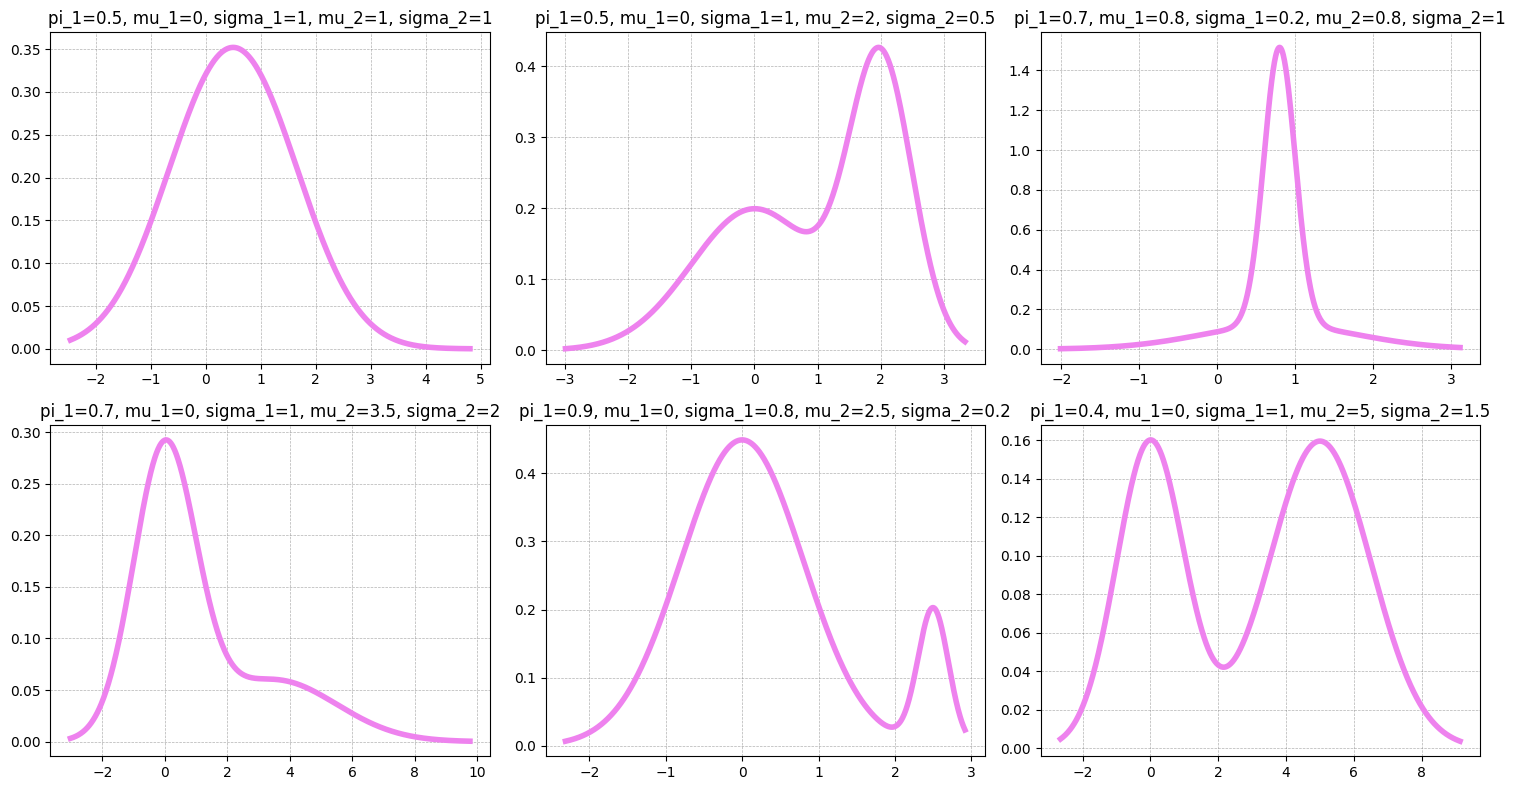

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 設定資料生成的參數
params = [
    {'pi_1': 0.5, 'mu_1': 0, 'sigma_1': 1, 'mu_2': 1, 'sigma_2': 1},
    {'pi_1': 0.5, 'mu_1': 0, 'sigma_1': 1, 'mu_2': 2, 'sigma_2': 0.5},
    {'pi_1': 0.7, 'mu_1': 0.8, 'sigma_1': 0.2, 'mu_2': 0.8, 'sigma_2': 1},
    {'pi_1': 0.7, 'mu_1': 0, 'sigma_1': 1, 'mu_2': 3.5, 'sigma_2': 2},
    {'pi_1': 0.9, 'mu_1': 0, 'sigma_1': 0.8, 'mu_2': 2.5, 'sigma_2': 0.2},
    {'pi_1': 0.4, 'mu_1': 0, 'sigma_1': 1, 'mu_2': 5, 'sigma_2': 1.5}
]

# 生成資料
def generate_data(pi_1, mu_1, sigma_1, mu_2, sigma_2, size=1000):
    n1 = int(size * pi_1)
    n2 = size - n1
    data1 = np.random.normal(mu_1, sigma_1, n1)
    data2 = np.random.normal(mu_2, sigma_2, n2)
    return np.concatenate([data1, data2])

# 繪製六張小圖
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for i, param in enumerate(params):
    data = generate_data(**param)
    ax = axs[i // 3, i % 3]
    
    # 繪製 PDF
    x = np.linspace(min(data), max(data), 1000)
    pdf1 = param['pi_1'] * norm.pdf(x, param['mu_1'], param['sigma_1'])
    pdf2 = (1 - param['pi_1']) * norm.pdf(x, param['mu_2'], param['sigma_2'])
    ax.plot(x, pdf1 + pdf2, 'violet', linewidth=4)
    ax.grid(True, linestyle='--', alpha=0.6, color='gray', linewidth=0.5)
    
    ax.set_title(f"pi_1={param['pi_1']}, mu_1={param['mu_1']}, sigma_1={param['sigma_1']}, mu_2={param['mu_2']}, sigma_2={param['sigma_2']}")

plt.tight_layout()
plt.show()

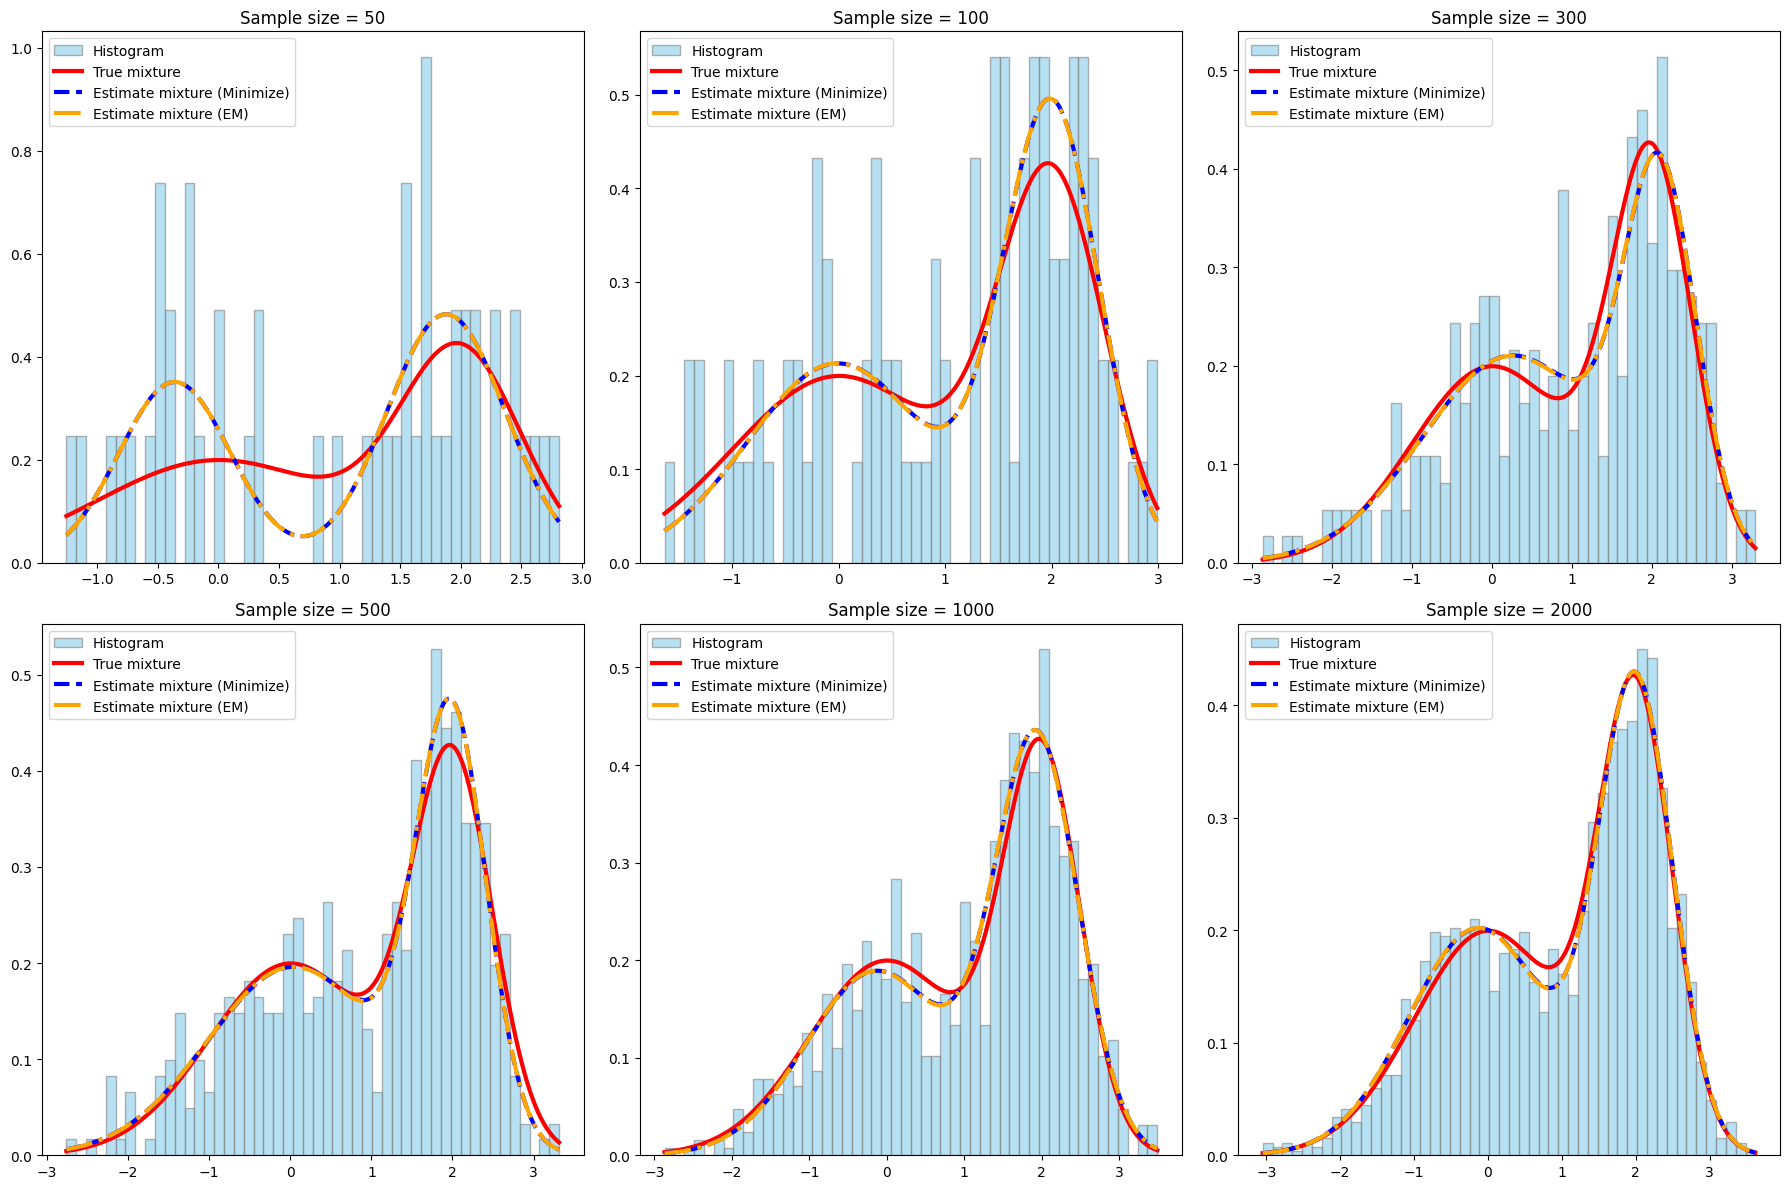

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

# 設定資料生成的參數
true_params = {'pi_1': 0.5, 'mu_1': 0, 'sigma_1': 1, 'mu_2': 2, 'sigma_2': 0.5}

# 設定實驗參數
n_values = [50, 100, 300, 500, 1000, 2000]  # 樣本大小
N = 10000  # 重複實驗次數

# 生成資料
def generate_data(pi_1, mu_1, sigma_1, mu_2, sigma_2, size):
    n1 = int(size * pi_1)
    n2 = size - n1
    data1 = np.random.normal(mu_1, sigma_1, n1)
    data2 = np.random.normal(mu_2, sigma_2, n2)
    return np.concatenate([data1, data2])

# 定義負對數似然函數
def neg_log_likelihood(params, data):
    pi_1, mu_1, sigma_1, mu_2, sigma_2 = params
    likelihood = pi_1 * norm.pdf(data, mu_1, sigma_1) + (1 - pi_1) * norm.pdf(data, mu_2, sigma_2)
    return -np.sum(np.log(likelihood))

# 繪製六張小圖
fig, axs = plt.subplots(2, 3, figsize=(18, 12))

for i, n in enumerate(n_values):
    data = generate_data(**true_params, size=n)
    
    # 使用 optimize.minimize 進行參數估計
    initial_params = [0.5, 0, 1, 2, 0.5]
    bounds = [(0, 1), (None, None), (1e-6, None), (None, None), (1e-6, None)]
    result = minimize(neg_log_likelihood, initial_params, args=(data,), bounds=bounds)
    if result.success:
        pi_1_min, mu_1_min, sigma_1_min, mu_2_min, sigma_2_min = result.x
    
    # 使用 sklearn.mixture.GaussianMixture 進行參數估計
    gmm = GaussianMixture(n_components=2, covariance_type='full', tol=1e-6, max_iter=1000)
    gmm.fit(data.reshape(-1, 1))
    pi_1_em = gmm.weights_[0]
    mu_1_em, mu_2_em = gmm.means_.flatten()
    sigma_1_em, sigma_2_em = np.sqrt(gmm.covariances_.flatten())
    
    ax = axs[i // 3, i % 3]
    ax.hist(data, bins=50, density=True, alpha=0.6, color='skyblue', label='Histogram', edgecolor='gray')
    
    # 繪製真實混合分佈的 PDF
    x = np.linspace(min(data), max(data), 1000)
    pdf_true = true_params['pi_1'] * norm.pdf(x, true_params['mu_1'], true_params['sigma_1']) + \
               (1 - true_params['pi_1']) * norm.pdf(x, true_params['mu_2'], true_params['sigma_2'])
    ax.plot(x, pdf_true, 'r', label='True mixture', linewidth=3)
    
    # 繪製 optimize.minimize 估計的混合分佈的 PDF
    pdf_min = pi_1_min * norm.pdf(x, mu_1_min, sigma_1_min) + \
              (1 - pi_1_min) * norm.pdf(x, mu_2_min, sigma_2_min)
    ax.plot(x, pdf_min, 'b', label='Estimate mixture (Minimize)', linestyle='--', linewidth=3)
    
    # 繪製 EM 估計的混合分佈的 PDF
    pdf_em = pi_1_em * norm.pdf(x, mu_1_em, sigma_1_em) + \
             (1 - pi_1_em) * norm.pdf(x, mu_2_em, sigma_2_em)
    ax.plot(x, pdf_em, 'orange', label='Estimate mixture (EM)', linewidth=3, linestyle='-.')
    
    ax.set_title(f'Sample size = {n}')
    ax.legend()

plt.tight_layout()
plt.show()

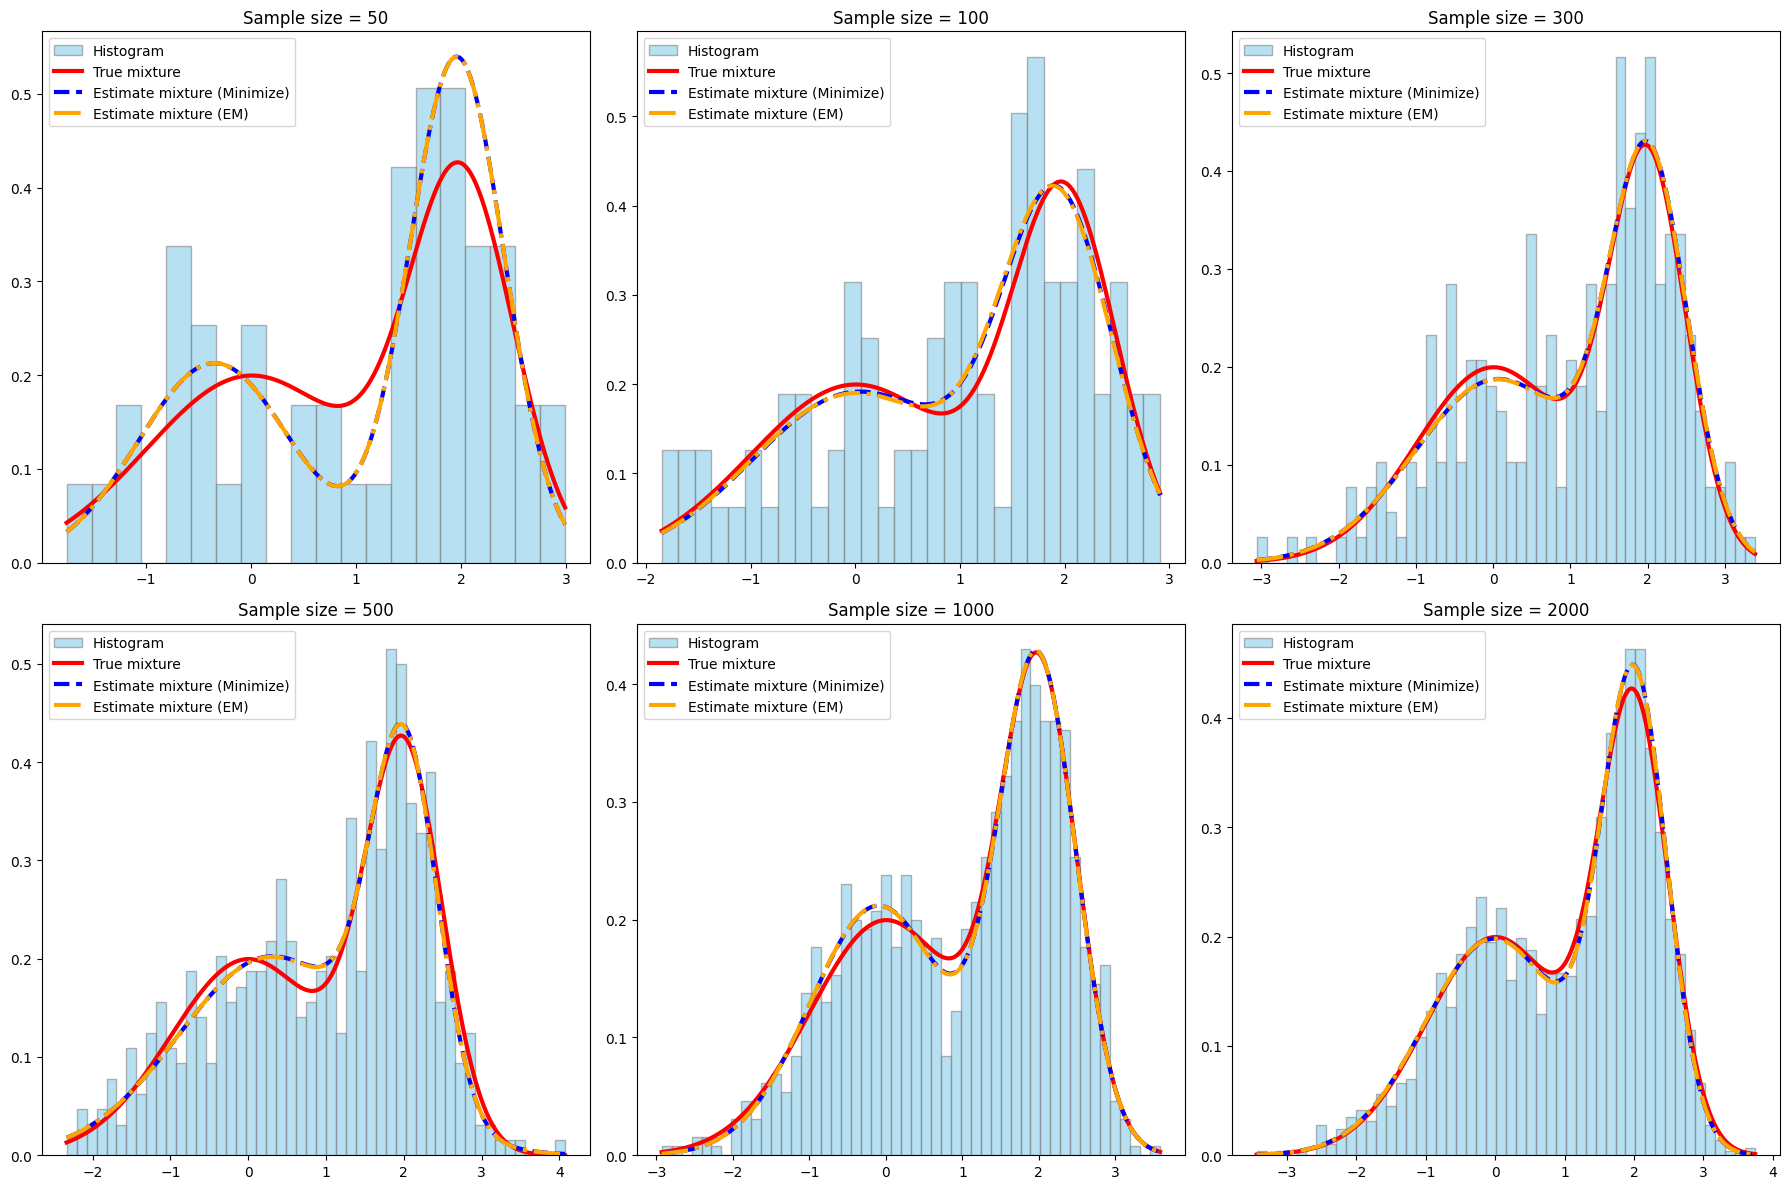

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

# 設定資料生成的參數
true_params = {'pi_1': 0.5, 'mu_1': 0, 'sigma_1': 1, 'mu_2': 2, 'sigma_2': 0.5}

# 設定實驗參數
n_values = [50, 100, 300, 500, 1000, 2000]  # 樣本大小
N = 10000  # 重複實驗次數

# 生成資料
def generate_data(pi_1, mu_1, sigma_1, mu_2, sigma_2, size):
    n1 = int(size * pi_1)
    n2 = size - n1
    data1 = np.random.normal(mu_1, sigma_1, n1)
    data2 = np.random.normal(mu_2, sigma_2, n2)
    return np.concatenate([data1, data2])

# 定義負對數似然函數
def neg_log_likelihood(params, data):
    pi_1, mu_1, sigma_1, mu_2, sigma_2 = params
    likelihood = pi_1 * norm.pdf(data, mu_1, sigma_1) + (1 - pi_1) * norm.pdf(data, mu_2, sigma_2)
    return -np.sum(np.log(likelihood))

# 繪製六張小圖
fig, axs = plt.subplots(2, 3, figsize=(18, 12))

# 手動調整每張圖的 bin 數
bins_list = [20, 30, 50, 50, 50, 50]

for i, (n, bins) in enumerate(zip(n_values, bins_list)):
    data = generate_data(**true_params, size=n)
    
    # 使用 optimize.minimize 進行參數估計
    initial_params = [0.5, 0, 1, 2, 0.5]
    bounds = [(0, 1), (None, None), (1e-6, None), (None, None), (1e-6, None)]
    result = minimize(neg_log_likelihood, initial_params, args=(data,), bounds=bounds)
    if result.success:
        pi_1_min, mu_1_min, sigma_1_min, mu_2_min, sigma_2_min = result.x
    
    # 使用 sklearn.mixture.GaussianMixture 進行參數估計
    gmm = GaussianMixture(n_components=2, covariance_type='full', tol=1e-6, max_iter=1000)
    gmm.fit(data.reshape(-1, 1))
    pi_1_em = gmm.weights_[0]
    mu_1_em, mu_2_em = gmm.means_.flatten()
    sigma_1_em, sigma_2_em = np.sqrt(gmm.covariances_.flatten())
    
    ax = axs[i // 3, i % 3]
    ax.hist(data, bins=bins, density=True, alpha=0.6, color='skyblue', label='Histogram', edgecolor='gray')
    
    # 繪製真實混合分佈的 PDF
    x = np.linspace(min(data), max(data), 1000)
    pdf_true = true_params['pi_1'] * norm.pdf(x, true_params['mu_1'], true_params['sigma_1']) + \
               (1 - true_params['pi_1']) * norm.pdf(x, true_params['mu_2'], true_params['sigma_2'])
    ax.plot(x, pdf_true, 'r', label='True mixture', linewidth=3)
    
    # 繪製 optimize.minimize 估計的混合分佈的 PDF
    pdf_min = pi_1_min * norm.pdf(x, mu_1_min, sigma_1_min) + \
              (1 - pi_1_min) * norm.pdf(x, mu_2_min, sigma_2_min)
    ax.plot(x, pdf_min, 'b', label='Estimate mixture (Minimize)', linestyle='--', linewidth=3)
    
    # 繪製 EM 估計的混合分佈的 PDF
    pdf_em = pi_1_em * norm.pdf(x, mu_1_em, sigma_1_em) + \
             (1 - pi_1_em) * norm.pdf(x, mu_2_em, sigma_2_em)
    ax.plot(x, pdf_em, 'orange', label='Estimate mixture (EM)', linewidth=3, linestyle='-.')
    
    ax.set_title(f'Sample size = {n}')
    ax.legend()

plt.tight_layout()
plt.show()

In [66]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

# 設定資料生成的參數
true_params = {'pi_1': 0.5, 'mu_1': 0, 'sigma_1': 1, 'mu_2': 2, 'sigma_2': 0.5}

# 設定實驗參數
n_values = [50, 100, 300, 500, 1000, 2000]  # 樣本大小
N = 10  # 重複實驗次數

# 生成資料
def generate_data(pi_1, mu_1, sigma_1, mu_2, sigma_2, size):
    n1 = int(size * pi_1)
    n2 = size - n1
    data1 = np.random.normal(mu_1, sigma_1, n1)
    data2 = np.random.normal(mu_2, sigma_2, n2)
    return np.concatenate([data1, data2])

# 定義負對數似然函數
def neg_log_likelihood(params, data):
    pi_1, mu_1, sigma_1, mu_2, sigma_2 = params
    likelihood = pi_1 * norm.pdf(data, mu_1, sigma_1) + (1 - pi_1) * norm.pdf(data, mu_2, sigma_2)
    return -np.sum(np.log(likelihood))

# 儲存結果
results_minimize = {param: [] for param in true_params}
results_em = {param: [] for param in true_params}

# 進行實驗
for n in n_values:
    for _ in range(N):
        data = generate_data(**true_params, size=n)
        
        # 使用 optimize.minimize 進行參數估計
        initial_params = [0.5, 0, 1, 2, 0.5]
        bounds = [(0, 1), (None, None), (1e-6, None), (None, None), (1e-6, None)]
        result = minimize(neg_log_likelihood, initial_params, args=(data,), bounds=bounds)
        if result.success:
            pi_1_min, mu_1_min, sigma_1_min, mu_2_min, sigma_2_min = result.x
            results_minimize['pi_1'].append(pi_1_min)
            results_minimize['mu_1'].append(mu_1_min)
            results_minimize['sigma_1'].append(sigma_1_min)
            results_minimize['mu_2'].append(mu_2_min)
            results_minimize['sigma_2'].append(sigma_2_min)
        
        # 使用 sklearn.mixture.GaussianMixture 進行參數估計
        gmm = GaussianMixture(n_components=2, covariance_type='full', tol=1e-6, max_iter=1000)
        gmm.fit(data.reshape(-1, 1))
        pi_1_em = gmm.weights_[0]
        mu_1_em, mu_2_em = gmm.means_.flatten()
        sigma_1_em, sigma_2_em = np.sqrt(gmm.covariances_.flatten())
        results_em['pi_1'].append(pi_1_em)
        results_em['mu_1'].append(mu_1_em)
        results_em['sigma_1'].append(sigma_1_em)
        results_em['mu_2'].append(mu_2_em)
        results_em['sigma_2'].append(sigma_2_em)

# 計算 Mean, Bias, RMSE
def calculate_statistics(estimated_values, true_value):
    mean = np.mean(estimated_values)
    bias = mean - true_value
    rmse = np.sqrt(np.mean((np.array(estimated_values) - true_value) ** 2))
    return mean, bias, rmse

statistics_minimize = {param: {'Mean': [], 'Bias': [], 'RMSE': []} for param in true_params}
statistics_em = {param: {'Mean': [], 'Bias': [], 'RMSE': []} for param in true_params}

for param in true_params:
    for n in n_values:
        mean, bias, rmse = calculate_statistics(results_minimize[param], true_params[param])
        statistics_minimize[param]['Mean'].append(mean)
        statistics_minimize[param]['Bias'].append(bias)
        statistics_minimize[param]['RMSE'].append(rmse)
        
        mean, bias, rmse = calculate_statistics(results_em[param], true_params[param])
        statistics_em[param]['Mean'].append(mean)
        statistics_em[param]['Bias'].append(bias)
        statistics_em[param]['RMSE'].append(rmse)

# 建立 pandas 表格
df_minimize_mean = pd.DataFrame({param: statistics_minimize[param]['Mean'] for param in true_params}, index=n_values)
df_minimize_bias = pd.DataFrame({param: statistics_minimize[param]['Bias'] for param in true_params}, index=n_values)
df_minimize_rmse = pd.DataFrame({param: statistics_minimize[param]['RMSE'] for param in true_params}, index=n_values)

df_em_mean = pd.DataFrame({param: statistics_em[param]['Mean'] for param in true_params}, index=n_values)
df_em_bias = pd.DataFrame({param: statistics_em[param]['Bias'] for param in true_params}, index=n_values)
df_em_rmse = pd.DataFrame({param: statistics_em[param]['RMSE'] for param in true_params}, index=n_values)

# 顯示 pandas 表格
print("Minimize Mean:")
print(df_minimize_mean)
print("\nMinimize Bias:")
print(df_minimize_bias)
print("\nMinimize RMSE:")
print(df_minimize_rmse)

print("\nEM Mean:")
print(df_em_mean)
print("\nEM Bias:")
print(df_em_bias)
print("\nEM RMSE:")
print(df_em_rmse)

Minimize Mean:
          pi_1      mu_1   sigma_1      mu_2  sigma_2
50    0.476658 -0.048309  0.930095  1.970689  0.50467
100   0.476658 -0.048309  0.930095  1.970689  0.50467
300   0.476658 -0.048309  0.930095  1.970689  0.50467
500   0.476658 -0.048309  0.930095  1.970689  0.50467
1000  0.476658 -0.048309  0.930095  1.970689  0.50467
2000  0.476658 -0.048309  0.930095  1.970689  0.50467

Minimize Bias:
          pi_1      mu_1   sigma_1      mu_2  sigma_2
50   -0.023342 -0.048309 -0.069905 -0.029311  0.00467
100  -0.023342 -0.048309 -0.069905 -0.029311  0.00467
300  -0.023342 -0.048309 -0.069905 -0.029311  0.00467
500  -0.023342 -0.048309 -0.069905 -0.029311  0.00467
1000 -0.023342 -0.048309 -0.069905 -0.029311  0.00467
2000 -0.023342 -0.048309 -0.069905 -0.029311  0.00467

Minimize RMSE:
          pi_1      mu_1  sigma_1     mu_2   sigma_2
50    0.081504  0.208554  0.15597  0.10207  0.069632
100   0.081504  0.208554  0.15597  0.10207  0.069632
300   0.081504  0.208554  0.15597  0.1

In [69]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

# 設定資料生成的參數
true_params = {'pi_1': 0.5, 'mu_1': 0, 'sigma_1': 1, 'mu_2': 2, 'sigma_2': 0.5}

# 設定實驗參數
n_values = [50, 100, 300, 500, 1000, 2000]  # 樣本大小
N = 1000  # 重複實驗次數

# 生成資料
def generate_data(pi_1, mu_1, sigma_1, mu_2, sigma_2, size):
    n1 = int(size * pi_1)
    n2 = size - n1
    data1 = np.random.normal(mu_1, sigma_1, n1)
    data2 = np.random.normal(mu_2, sigma_2, n2)
    return np.concatenate([data1, data2])

# 定義負對數似然函數
def neg_log_likelihood(params, data):
    pi_1, mu_1, sigma_1, mu_2, sigma_2 = params
    likelihood = pi_1 * norm.pdf(data, mu_1, sigma_1) + (1 - pi_1) * norm.pdf(data, mu_2, sigma_2)
    return -np.sum(np.log(likelihood))

# 儲存結果
results_minimize = {param: [] for param in true_params}
results_em = {param: [] for param in true_params}

# 進行實驗
for n in n_values:
    for _ in range(N):
        data = generate_data(**true_params, size=n)
        
        # 使用 optimize.minimize 進行參數估計
        initial_params = [0.5, 0, 1, 2, 0.5]
        bounds = [(0, 1), (None, None), (1e-6, None), (None, None), (1e-6, None)] #
        result = minimize(neg_log_likelihood, initial_params, args=(data,), bounds=bounds)
        if result.success:
            pi_1_min, mu_1_min, sigma_1_min, mu_2_min, sigma_2_min = result.x
            results_minimize['pi_1'].append(pi_1_min)
            results_minimize['mu_1'].append(mu_1_min)
            results_minimize['sigma_1'].append(sigma_1_min)
            results_minimize['mu_2'].append(mu_2_min)
            results_minimize['sigma_2'].append(sigma_2_min)
        
        # 使用 sklearn.mixture.GaussianMixture 進行參數估計
        gmm = GaussianMixture(n_components=2, covariance_type='full', tol=1e-6, max_iter=1000,
                              weights_init=[0.5, 0.5],
                              means_init=np.array([0, 2]).reshape(2, 1))
        gmm.fit(data.reshape(-1, 1))
        pi_1_em = gmm.weights_[0]
        mu_1_em, mu_2_em = gmm.means_.flatten()
        sigma_1_em, sigma_2_em = np.sqrt(gmm.covariances_.flatten())
        results_em['pi_1'].append(pi_1_em)
        results_em['mu_1'].append(mu_1_em)
        results_em['sigma_1'].append(sigma_1_em)
        results_em['mu_2'].append(mu_2_em)
        results_em['sigma_2'].append(sigma_2_em)

# 計算 Mean, Bias, RMSE
def calculate_statistics(estimated_values, true_value):
    mean = np.mean(estimated_values)
    bias = mean - true_value
    rmse = np.sqrt(np.mean((np.array(estimated_values) - true_value) ** 2))
    return mean, bias, rmse

statistics_minimize = {param: {'Mean': [], 'Bias': [], 'RMSE': []} for param in true_params}
statistics_em = {param: {'Mean': [], 'Bias': [], 'RMSE': []} for param in true_params}

for param in true_params:
    for n in n_values:
        mean, bias, rmse = calculate_statistics(results_minimize[param], true_params[param])
        statistics_minimize[param]['Mean'].append(mean)
        statistics_minimize[param]['Bias'].append(bias)
        statistics_minimize[param]['RMSE'].append(rmse)
        
        mean, bias, rmse = calculate_statistics(results_em[param], true_params[param])
        statistics_em[param]['Mean'].append(mean)
        statistics_em[param]['Bias'].append(bias)
        statistics_em[param]['RMSE'].append(rmse)

# 建立 pandas 表格
df_minimize_mean = pd.DataFrame({param: statistics_minimize[param]['Mean'] for param in true_params}, index=n_values)
df_minimize_bias = pd.DataFrame({param: statistics_minimize[param]['Bias'] for param in true_params}, index=n_values)
df_minimize_rmse = pd.DataFrame({param: statistics_minimize[param]['RMSE'] for param in true_params}, index=n_values)

df_em_mean = pd.DataFrame({param: statistics_em[param]['Mean'] for param in true_params}, index=n_values)
df_em_bias = pd.DataFrame({param: statistics_em[param]['Bias'] for param in true_params}, index=n_values)
df_em_rmse = pd.DataFrame({param: statistics_em[param]['RMSE'] for param in true_params}, index=n_values)

# 顯示 pandas 表格
print("Minimize Mean:")
print(df_minimize_mean)
print("\nMinimize Bias:")
print(df_minimize_bias)
print("\nMinimize RMSE:")
print(df_minimize_rmse)

print("\nEM Mean:")
print(df_em_mean)
print("\nEM Bias:")
print(df_em_bias)
print("\nEM RMSE:")
print(df_em_rmse)

/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_26054/2754040453.py:26: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(likelihood))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_26054/2754040453.py:26: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(likelihood))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


Minimize Mean:
          pi_1     mu_1   sigma_1      mu_2   sigma_2
50    0.494862 -0.02721  0.967621  1.988859  0.494422
100   0.494862 -0.02721  0.967621  1.988859  0.494422
300   0.494862 -0.02721  0.967621  1.988859  0.494422
500   0.494862 -0.02721  0.967621  1.988859  0.494422
1000  0.494862 -0.02721  0.967621  1.988859  0.494422
2000  0.494862 -0.02721  0.967621  1.988859  0.494422

Minimize Bias:
          pi_1     mu_1   sigma_1      mu_2   sigma_2
50   -0.005138 -0.02721 -0.032379 -0.011141 -0.005578
100  -0.005138 -0.02721 -0.032379 -0.011141 -0.005578
300  -0.005138 -0.02721 -0.032379 -0.011141 -0.005578
500  -0.005138 -0.02721 -0.032379 -0.011141 -0.005578
1000 -0.005138 -0.02721 -0.032379 -0.011141 -0.005578
2000 -0.005138 -0.02721 -0.032379 -0.011141 -0.005578

Minimize RMSE:
          pi_1      mu_1   sigma_1      mu_2   sigma_2
50    0.070854  0.233216  0.147438  0.099622  0.075898
100   0.070854  0.233216  0.147438  0.099622  0.075898
300   0.070854  0.233216  0.1474